In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Ensemble
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

import warnings
warnings.filterwarnings('ignore')

In [36]:
# This peace of code comes from the EDA notebook

data = pd.read_csv("../data/updated_pollution_dataset.csv")

target_col = data.columns[-1]

quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}

data[target_col] = data[target_col].map(quality_map)
data[target_col] = data[target_col].astype("int8")

In [37]:
X, y = data.drop(columns=data.columns[-1]), data[data.columns[-1]]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

---
## Helper: función de evaluación

Definimos una función reutilizable que calcula las 4 métricas para cualquier modelo.  
La llamaremos al final de cada sección y en la comparativa global.

| Métrica | Cuándo es útil |
|---|---|
| **Accuracy** | Referencia rápida, solo fiable con clases balanceadas |
| **Macro F1** | Principal: penaliza igual fallar en clases raras (Hazardous) que en comunes |
| **Weighted F1** | Pondera por frecuencia de clase, más permisivo con clases minoritarias |
| **Cohen's Kappa** | Descuenta el acierto por azar; 0 = azar, 1 = perfecto |

In [4]:
CLASS_NAMES = ['Hazardous', 'Poor', 'Moderate', 'Good']

def evaluate(model, X_eval, y_true, name='Modelo'):
    """Evalúa un modelo e imprime las 4 métricas clave."""
    y_pred = model.predict(X_eval)
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_wgt = f1_score(y_true, y_pred, average='weighted')
    kappa  = cohen_kappa_score(y_true, y_pred)
    print(f"{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Macro F1       : {f1_mac:.4f}  ← principal")
    print(f"  Weighted F1    : {f1_wgt:.4f}")
    print(f"  Cohen's Kappa  : {kappa:.4f}")
    return {'Modelo': name, 'Accuracy': acc, 'Macro F1': f1_mac,
            'Weighted F1': f1_wgt, "Cohen's Kappa": kappa}

In [5]:
# Definimos los modelos base
lr_clf  = LogisticRegression(max_iter=1000, random_state=42)
rf_clf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(probability=True, random_state=42)   # probability=True → necesario para soft voting

# ── Hard Voting ──
hard_voting = VotingClassifier(
    estimators=[('lr', lr_clf), ('rf', rf_clf), ('svm', svm_clf)],
    voting='hard'
)
hard_voting.fit(X_train_sc, y_train)
hv_metrics = evaluate(hard_voting, X_test_sc, y_test, 'Hard Voting')

─────────────────────────────────────────────
  Hard Voting
─────────────────────────────────────────────
  Accuracy       : 0.9536
  Macro F1       : 0.9328  ← principal
  Weighted F1    : 0.9531
  Cohen's Kappa  : 0.9335


In [6]:
# Accuracy de cada estimador individual
print("Accuracy por estimador:")
for name, clf in hard_voting.named_estimators_.items():
    print(f"  {name:5s} = {clf.score(X_test_sc, y_test):.4f}")

# Predicción de los 3 modelos sobre la primera muestra del test
print("\nPredicciones para X_test[0]:")
print([clf.predict(X_test_sc[:1]) for clf in hard_voting.estimators_])

Accuracy por estimador:
  lr    = 0.9496
  rf    = 0.9528
  svm   = 0.9512

Predicciones para X_test[0]:
[array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)]


In [7]:
hard_voting.voting = 'soft'
hard_voting.fit(X_train_sc, y_train)
sv_metrics = evaluate(hard_voting, X_test_sc, y_test, 'Soft Voting')

# Volvemos a guardar hard voting entrenado para la comparativa
hard_voting.voting = 'hard'
hard_voting.fit(X_train_sc, y_train)

─────────────────────────────────────────────
  Soft Voting
─────────────────────────────────────────────
  Accuracy       : 0.9576
  Macro F1       : 0.9384  ← principal
  Weighted F1    : 0.9573
  Cohen's Kappa  : 0.9392


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


## 2. Bagging vs Pasting


In [ ]:
bag_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=500, max_samples=100, oob_score=True, random_state=42)
past_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=500, max_samples=100,bootstrap=False, oob_score=False, random_state=42)

bag_classifier.fit(X_train, y_train)
past_classifier.fit(X_train, y_train)

print("Bagging - Out Of Bag \"OOB\" Score: ", bag_classifier.oob_score_)
print("Bagging (Replacement) Test Score: ", bag_classifier.score(X_test, y_test))
print("Pasting (No Replacement) Test Score: ", past_classifier.score(X_test, y_test))

print(f"Bagging  – OOB Score: {bag_clf.oob_score_:.4f}  (estimación sin usar el test set)\n")
bag_metrics  = evaluate(bag_clf,  X_test, y_test, 'Bagging')
past_metrics = evaluate(past_clf, X_test, y_test, 'Pasting')

Bagging  – OOB Score: 0.9237  (estimación sin usar el test set)

─────────────────────────────────────────────
  Bagging
─────────────────────────────────────────────
  Accuracy       : 0.9232
  Macro F1       : 0.8996  ← principal
  Weighted F1    : 0.9228
  Cohen's Kappa  : 0.8898
─────────────────────────────────────────────
  Pasting
─────────────────────────────────────────────
  Accuracy       : 0.9208
  Macro F1       : 0.8972  ← principal
  Weighted F1    : 0.9205
  Cohen's Kappa  : 0.8863


In [9]:
# El OOB Score por clase nos dice cómo de bien predice cada clase
# oob_decision_function_ tiene forma (n_samples, n_classes)
oob_proba = bag_clf.oob_decision_function_
oob_pred  = np.argmax(oob_proba, axis=1)   # clase con mayor prob

# Mapeamos los índices a las clases originales
classes = bag_clf.classes_
oob_pred_mapped = classes[oob_pred]

print("OOB Classification Report:")
print(classification_report(y_train, oob_pred_mapped,
                            target_names=['Hazardous','Poor','Moderate','Good']))

OOB Classification Report:
              precision    recall  f1-score   support

   Hazardous       0.92      0.73      0.82       375
        Poor       0.81      0.86      0.83       750
    Moderate       0.92      0.94      0.93      1125
        Good       0.99      0.99      0.99      1500

    accuracy                           0.92      3750
   macro avg       0.91      0.88      0.89      3750
weighted avg       0.92      0.92      0.92      3750



---
## 3. Boosting

Los modelos se entrenan **secuencialmente**: cada uno intenta corregir los errores del anterior.

### 3a. AdaBoost
Aumenta el peso de las muestras mal clasificadas en cada iteración. El estimador base suele ser un árbol poco profundo ("weak learner").

In [38]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=200,
    learning_rate=0.5,
    algorithm='SAMME',   # versión actual de AdaBoost
    random_state=42
)
ada_clf.fit(X_train, y_train)
print(f"AdaBoost – Test Accuracy: {ada_clf.score(X_test, y_test):.4f}")

AdaBoost – Test Accuracy: 0.9440


In [11]:
# GridSearch para encontrar los mejores hiperparámetros de AdaBoost
params = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                       algorithm='SAMME', random_state=42),
    params, cv=3, scoring='accuracy', n_jobs=-1
)
ada_grid.fit(X_train, y_train)

print(f"Mejores parámetros: {ada_grid.best_params_}")
ada_metrics = evaluate(ada_grid.best_estimator_, X_test, y_test, 'AdaBoost')

Mejores parámetros: {'learning_rate': 0.1, 'n_estimators': 200}
─────────────────────────────────────────────
  AdaBoost
─────────────────────────────────────────────
  Accuracy       : 0.9480
  Macro F1       : 0.9285  ← principal
  Weighted F1    : 0.9478
  Cohen's Kappa  : 0.9256


### 3b. Gradient Boosting
En lugar de ajustar pesos, cada árbol se entrena sobre los **residuos (errores)** del anterior. Más potente y flexible que AdaBoost.

In [12]:
gb_clf = GradientBoostingClassifier(
    max_depth=3,
    n_estimators=300,
    learning_rate=0.1,
    n_iter_no_change=10,   # early stopping: para si no mejora en 10 iteraciones
    validation_fraction=0.1,
    random_state=42
)
gb_clf.fit(X_train, y_train)

print(f"GradientBoosting – Estimadores usados (early stopping): {gb_clf.n_estimators_}\n")
gb_metrics = evaluate(gb_clf, X_test, y_test, 'GradientBoosting')

GradientBoosting – Estimadores usados (early stopping): 92

─────────────────────────────────────────────
  GradientBoosting
─────────────────────────────────────────────
  Accuracy       : 0.9488
  Macro F1       : 0.9278  ← principal
  Weighted F1    : 0.9483
  Cohen's Kappa  : 0.9266


---
## 4. XGBoost

Implementación optimizada de Gradient Boosting. Más rápido y con mejor regularización que el de sklearn.  
Añade regularización L1/L2 y soporte nativo para valores nulos.

In [13]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,          # bagging de muestras en cada árbol
    colsample_bytree=0.8,   # bagging de features
    eval_metric='mlogloss',
    early_stopping_rounds=10,
    random_state=42
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"XGBoost – Estimadores usados (early stopping): {xgb_clf.best_iteration}\n")
xgb_metrics = evaluate(xgb_clf, X_test, y_test, 'XGBoost')

XGBoost – Estimadores usados (early stopping): 147

─────────────────────────────────────────────
  XGBoost
─────────────────────────────────────────────
  Accuracy       : 0.9528
  Macro F1       : 0.9329  ← principal
  Weighted F1    : 0.9525
  Cohen's Kappa  : 0.9324


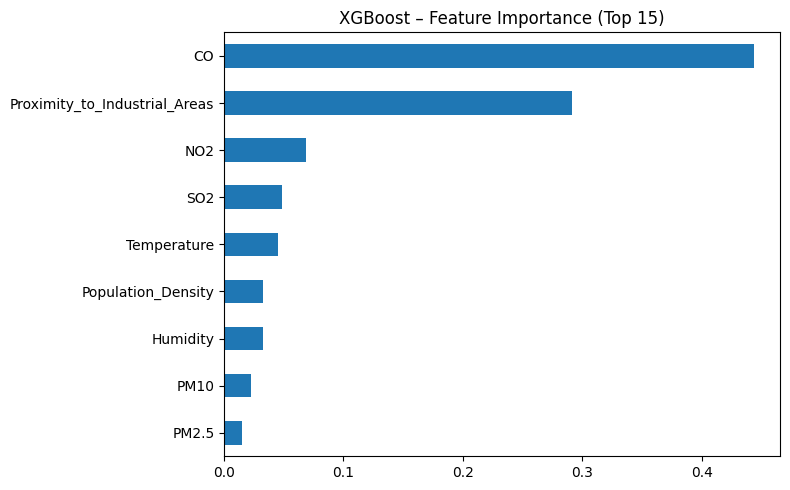

In [14]:
# Feature importance de XGBoost
importances = pd.Series(xgb_clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(15).plot(
    kind='barh', figsize=(8, 5), title='XGBoost – Feature Importance (Top 15)'
)
plt.tight_layout()
plt.show()

---
## 5. Stacking

Los modelos base generan predicciones que se usan como **features de entrada de un meta-modelo** (blender).  
- Nivel 1 (estimators): LR, RF, SVM  
- Nivel 2 (final_estimator): RandomForest como blender

In [15]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svm', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    cv=5,              # cross-val para generar el training set del blender
    n_jobs=-1
)

stacking_clf.fit(X_train_sc, y_train)
stack_metrics = evaluate(stacking_clf, X_test_sc, y_test, 'Stacking')

─────────────────────────────────────────────
  Stacking
─────────────────────────────────────────────
  Accuracy       : 0.9584
  Macro F1       : 0.9396  ← principal
  Weighted F1    : 0.9581
  Cohen's Kappa  : 0.9404


---
## 6. Comparativa final

In [16]:
# Unimos todos los dicts de métricas recogidos a lo largo del notebook
all_metrics = [
    hv_metrics, sv_metrics,
    bag_metrics, past_metrics,
    ada_metrics, gb_metrics,
    xgb_metrics, stack_metrics
]

results_df = pd.DataFrame(all_metrics).sort_values('Macro F1', ascending=False).reset_index(drop=True)

# Tabla con todas las métricas
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

          Modelo  Accuracy  Macro F1  Weighted F1  Cohen's Kappa
        Stacking    0.9584    0.9396       0.9581         0.9404
     Soft Voting    0.9576    0.9384       0.9573         0.9392
         XGBoost    0.9528    0.9329       0.9525         0.9324
     Hard Voting    0.9536    0.9328       0.9531         0.9335
        AdaBoost    0.9480    0.9285       0.9478         0.9256
GradientBoosting    0.9488    0.9278       0.9483         0.9266
         Bagging    0.9232    0.8996       0.9228         0.8898
         Pasting    0.9208    0.8972       0.9205         0.8863


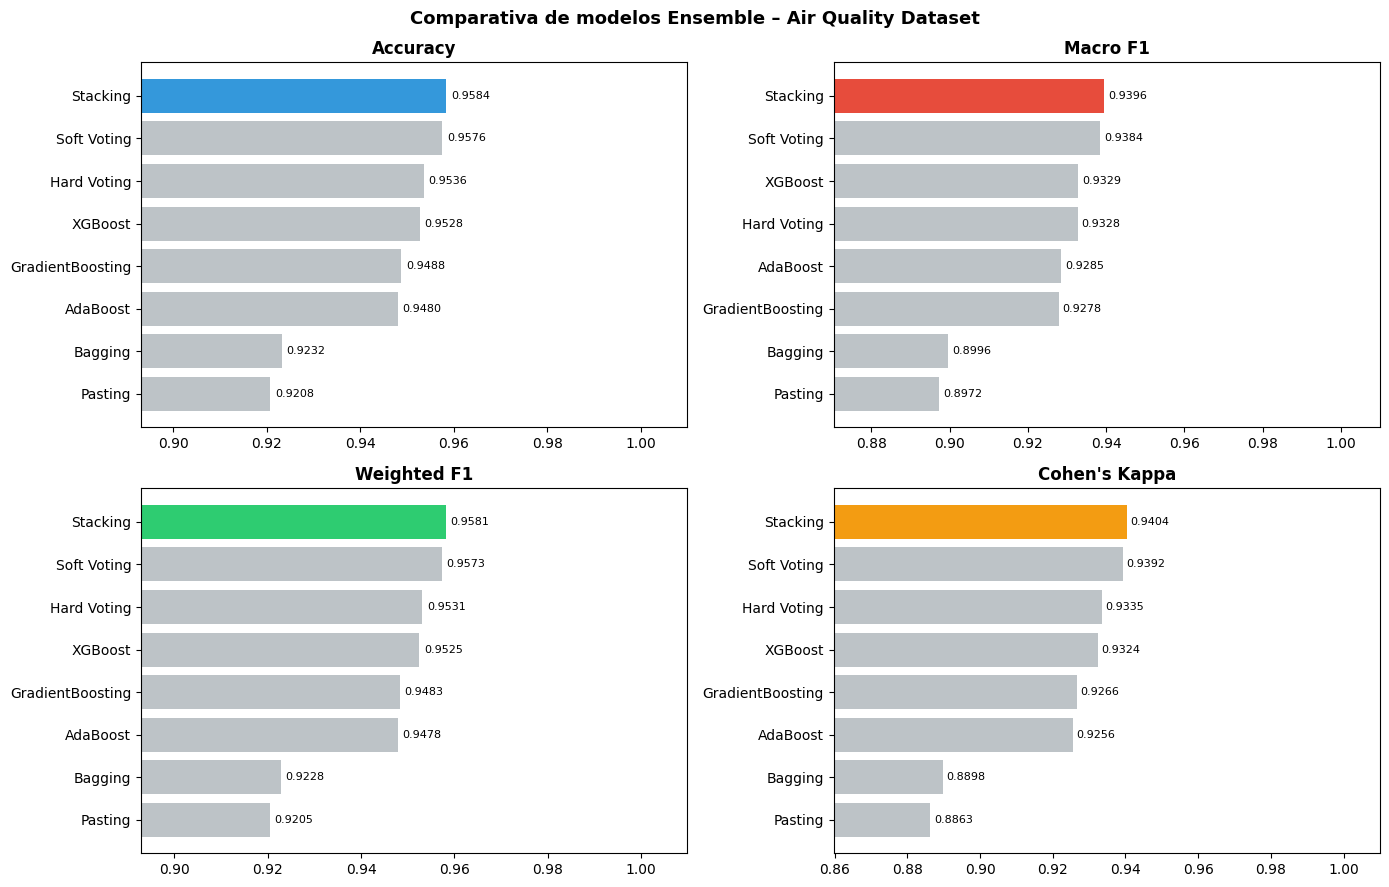

In [17]:
# Gráfico comparativo con las 4 métricas
metrics_cols = ['Accuracy', 'Macro F1', 'Weighted F1', "Cohen's Kappa"]
colors       = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col, color in zip(axes, metrics_cols, colors):
    df_sorted = results_df.sort_values(col, ascending=True)
    bar_colors = [color if v == df_sorted[col].max() else '#bdc3c7' for v in df_sorted[col]]
    bars = ax.barh(df_sorted['Modelo'], df_sorted[col], color=bar_colors)
    ax.set_title(col, fontweight='bold')
    ax.set_xlim(df_sorted[col].min() * 0.97, 1.01)
    for bar, val in zip(bars, df_sorted[col]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

fig.suptitle('Comparativa de modelos Ensemble – Air Quality Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Mejor modelo por Macro F1: Stacking

              precision    recall  f1-score   support

   Hazardous       0.94      0.86      0.90       125
        Poor       0.90      0.90      0.90       250
    Moderate       0.95      0.98      0.96       375
        Good       1.00      1.00      1.00       500

    accuracy                           0.96      1250
   macro avg       0.95      0.93      0.94      1250
weighted avg       0.96      0.96      0.96      1250



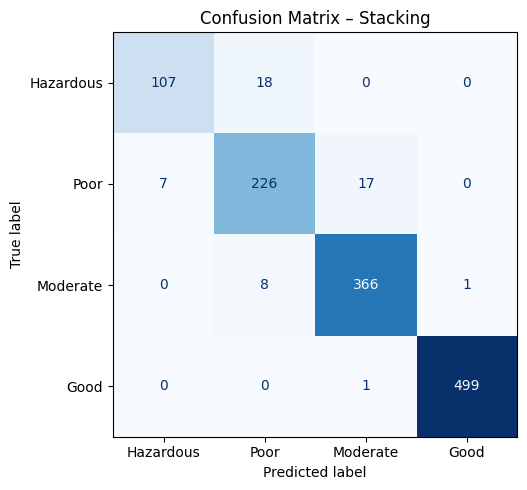

In [18]:
# ── Análisis por clase del mejor modelo (ordenado por Macro F1) ──
best_name   = results_df.iloc[0]['Modelo']
uses_scaled = best_name in ['Hard Voting', 'Soft Voting', 'Stacking']
X_eval      = X_test_sc if uses_scaled else X_test

model_map = {
    'Bagging': bag_clf, 'Pasting': past_clf,
    'AdaBoost': ada_grid.best_estimator_, 'GradientBoosting': gb_clf,
    'XGBoost': xgb_clf, 'Stacking': stacking_clf,
    'Hard Voting': hard_voting, 'Soft Voting': hard_voting
}

best_model = model_map[best_name]
y_pred     = best_model.predict(X_eval)

print(f"Mejor modelo por Macro F1: {best_name}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=CLASS_NAMES,
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion Matrix – {best_name}')
plt.tight_layout()
plt.show()

Recall para clase 'Hazardous' (cuántos casos peligrosos detecta cada modelo):
Stacking            0.856
Hard Voting         0.840
Soft Voting         0.840
AdaBoost            0.840
XGBoost             0.832
GradientBoosting    0.808
Pasting             0.768
Bagging             0.760


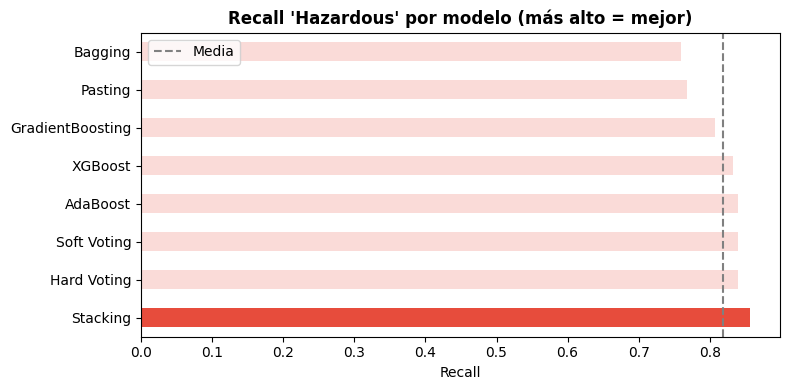

In [19]:
# ── Recall de clase 'Hazardous' en todos los modelos ──
# En un problema de calidad del aire, no detectar un caso Hazardous es el peor error posible.
# Queremos maximizar el Recall de esa clase.

from sklearn.metrics import recall_score

hazardous_recall = {}
for row in all_metrics:
    name  = row['Modelo']
    sc    = name in ['Hard Voting', 'Soft Voting', 'Stacking']
    Xe    = X_test_sc if sc else X_test
    model = model_map[name]
    yp    = model.predict(Xe)
    # recall por clase devuelve [Hazardous, Poor, Moderate, Good]
    recalls = recall_score(y_test, yp, average=None, labels=[0, 1, 2, 3])
    hazardous_recall[name] = recalls[0]   # índice 0 = Hazardous

haz_df = pd.Series(hazardous_recall).sort_values(ascending=False)
print("Recall para clase 'Hazardous' (cuántos casos peligrosos detecta cada modelo):")
print(haz_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#e74c3c' if v == haz_df.max() else '#fadbd8' for v in haz_df.values]
haz_df.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_title("Recall 'Hazardous' por modelo (más alto = mejor)", fontweight='bold')
ax.set_xlabel('Recall')
ax.axvline(x=haz_df.mean(), linestyle='--', color='gray', label='Media')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
import joblib

# Save the best model
joblib.dump(best_model, "../src/models/ensemble_model.pkl")

['../src/models/ensemble_model.pkl']